# Lecture 1 Tutorial — Spatial Analysis with Python
## Working with Real Fire Data in Peru

**Anzony Quispe · 2026**

---

### Learning Objectives

By the end of this tutorial you will be able to:

| # | Skill |
|---|-------|
| 1 | Load and inspect **point** and **polygon** vector data |
| 2 | Check and change a **CRS** (coordinate reference system) |
| 3 | Perform a **spatial join** — assign each fire to its region |
| 4 | **Aggregate** data (count fires per region) |
| 5 | Create a **choropleth map** with geopandas |
| 6 | Apply **buffers** to identify proximity zones |
| 7 | **Dissolve** polygons to create a country boundary |

---

### Dataset

**VIIRS-SNPP Active Fire Detections — Peru 2015**  
Source: [NASA FIRMS](https://firms.modaps.eosdis.nasa.gov/)  
Each row = one satellite fire detection (hotspot): latitude, longitude, date, fire radiative power (FRP), confidence.

**Peru Administrative Regions**  
Source: [GADM 4.1](https://gadm.org/) — 26 Level-1 regions.

## 0 · Setup

Run this cell once to install any missing packages.

In [31]:
# Uncomment and run once if needed
# !pip install geopandas shapely pyproj matplotlib pandas requests

In [32]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point

print('geopandas :', gpd.__version__)
print('pandas    :', pd.__version__)

geopandas : 1.1.1
pandas    : 2.3.3


---
## Part 1 — Loading & Understanding the Data

### 1.1  Fire Detections are Points

The **VIIRS satellite** (Visible Infrared Imaging Radiometer Suite) flies over the Earth twice a day and detects thermal anomalies — fires.  
Each detection is recorded as:

- `latitude`, `longitude` → **where** the fire was
- `acq_date` → **when** it was detected
- `frp` (fire radiative power, MW) → **how intense** it was
- `confidence` → how sure the satellite is it's a real fire

Spatially, every single fire detection is a **Point** geometry.  
A year of Peru data = ~70,000 points.

In [33]:
# Download VIIRS-SNPP fires for Peru 2015 directly from NASA FIRMS
YEAR = 2015
url = f'https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/{YEAR}/viirs-snpp_{YEAR}_Peru.csv'

fires_raw = pd.read_csv(url)
print(f'Rows: {len(fires_raw):,}   Columns: {fires_raw.shape[1]}')
fires_raw.head(3)

Rows: 69,996   Columns: 15


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,-17.20080,-70.95138,297.19,0.72,0.75,2015-01-01,509,N,VIIRS,n,2,286.28,2.81,N,0
1,-17.20262,-70.94351,298.24,0.72,0.75,2015-01-01,509,N,VIIRS,n,2,286.78,2.31,N,0
2,-17.20549,-70.95315,297.41,0.72,0.75,2015-01-01,509,N,VIIRS,n,2,286.69,2.71,N,0


**Key columns to understand:**

| Column | Meaning |
|--------|----------|
| `latitude`, `longitude` | Geographic coordinates (EPSG:4326) |
| `acq_date` | Acquisition date (YYYY-MM-DD) |
| `acq_time` | Acquisition time (HHMM integer, e.g. 509 = 05:09) |
| `frp` | Fire radiative power in megawatts |
| `confidence` | `h`=high, `n`=nominal, `l`=low |
| `daynight` | `D`=daytime, `N`=nighttime pass |

> ⚠️ Note: `acq_time` is an **integer** (HHMM format), not a date string. Always use `acq_date` to parse the date.

In [61]:
# Step 1: parse the acquisition date correctly
fires_raw['date'] = pd.to_datetime(fires_raw['acq_date'])
fires_raw['year']  = fires_raw['date'].dt.year
fires_raw['month'] = fires_raw['date'].dt.month

# Step 2: build a GeoDataFrame — add a geometry column
# Rule: in Shapely/GeoPandas → Point(longitude, latitude)  i.e. (x, y)
fires = gpd.GeoDataFrame(
    fires_raw,
    geometry=gpd.points_from_xy(fires_raw.longitude, fires_raw.latitude),
    crs='EPSG:4326'
)

print(f'Fire detections: {len(fires):,}')
print(f'CRS: {fires.crs}')
fires[['latitude','longitude','acq_date','year','month','frp','confidence','geometry']].head(5)

Fire detections: 69,996
CRS: EPSG:4326


,latitude,longitude,acq_date,year,month,frp,confidence,geometry
0,-17.20080,-70.95138,2015-01-01,2015,1,2.81,n,POINT (-70.95138 -17.2008)
1,-17.20262,-70.94351,2015-01-01,2015,1,2.31,n,POINT (-70.94351 -17.20262)
2,-17.20549,-70.95315,2015-01-01,2015,1,2.71,n,POINT (-70.95315 -17.20549)
3,-7.10503,-76.51246,2015-01-01,2015,1,1.21,n,POINT (-76.51246 -7.10503)
4,-17.49601,-71.36060,2015-01-01,2015,1,5.94,h,POINT (-71.3606 -17.49601)


We now have a **GeoDataFrame** — a regular pandas DataFrame with a special `geometry` column that stores spatial shapes.

Since each fire is a location in space → geometry type is **Point**.

In [35]:
# Quick statistical summary of fire intensity
print('Geometry type:', fires.geom_type.value_counts().to_dict())
print()
fires[['frp']].describe().round(2)

Geometry type: {'Point': 69996}



,frp
count,69996.00
mean,10.19
std,15.46
min,0.03
25%,3.55
50%,5.88
75%,10.56
max,562.08


### 1.2  Peru Regions are Polygons

Peru is divided into 26 administrative regions (Regiones).  
Each region is stored as a **Polygon** (or MultiPolygon) — a closed boundary with all the area inside it.

We download the shapefile from **GADM** — a free global administrative boundaries database.

In [62]:
# Download Peru Level-1 regions from GADM 4.1
peru = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_1.json'
)
# Keep only the columns we need
peru = peru[['GID_1', 'NAME_1', 'geometry']].copy()

print(f'Regions: {len(peru)}')
print(f'CRS    : {peru.crs}')
peru.head(5)

Regions: 26
CRS    : EPSG:4326


,GID_1,NAME_1,geometry
0,PER.1_1,Amazonas,"MULTIPOLYGON (((-77.7803 -6.942, -77.7842 -6.9..."
1,PER.2_1,Ancash,"MULTIPOLYGON (((-77.2862 -10.5582, -77.292 -10..."
2,PER.3_1,Apurímac,"MULTIPOLYGON (((-73.2403 -13.4763, -73.2363 -1..."
3,PER.4_1,Arequipa,"MULTIPOLYGON (((-71.8424 -17.1726, -71.8482 -1..."
4,PER.5_1,Ayacucho,"MULTIPOLYGON (((-73.2933 -15.3921, -73.3067 -1..."


In [37]:
# Check geometry type — regions can be MultiPolygon (islands, enclaves)
print('Geometry types in Peru regions:')
print(peru.geom_type.value_counts())

# Each region has an area (in degrees² — we'll fix this later)
peru['area_deg2'] = peru.geometry.area
peru[['NAME_1', 'area_deg2']].sort_values('area_deg2', ascending=False).head(5)

Geometry types in Peru regions:
MultiPolygon    26
Name: count, dtype: int64


,NAME_1,area_deg2
16,Loreto,30.591774
25,Ucayali,8.655988
17,MadredeDios,7.000569
21,Puno,6.109680
7,Cusco,6.024815


### 1.3  CRS — Coordinate Reference Systems

Both datasets are in **EPSG:4326** (WGS84 — degrees of latitude/longitude).  
This is fine for plotting, but **not** for computing distances or areas.

| CRS | Units | EPSG code | Use for |
|-----|-------|-----------|----------|
| WGS84 | degrees | 4326 | data exchange, plotting |
| UTM Zone 18S | meters | 32718 | distances, areas, buffers (Peru) |

**Three golden rules:**
1. Every dataset must have a CRS
2. Before computing distance or area → reproject to meters
3. All layers in an analysis must share the same CRS

In [38]:
# Always verify CRS before any analysis
print('Fires CRS :', fires.crs)
print('Peru  CRS :', peru.crs)
print('Same CRS? :', fires.crs == peru.crs)

Fires CRS : EPSG:4326
Peru  CRS : EPSG:4326
Same CRS? : True


In [39]:
# Correct way to compute area: reproject to UTM 18S (meters)
peru_m = peru.to_crs('EPSG:32718')
peru_m['area_km2'] = peru_m.geometry.area / 1e6   # m² → km²

print('Top 5 regions by area:')
peru_m[['NAME_1', 'area_km2']].sort_values('area_km2', ascending=False).head(5).round(0)

Top 5 regions by area:


,NAME_1,area_km2
16,Loreto,375527.0
25,Ucayali,105105.0
17,MadredeDios,84786.0
21,Puno,73178.0
7,Cusco,72369.0


### 1.4  First Visualization — Both Layers Together

Let's overlay the fire points on top of the Peru region polygons to make sure everything is in the right place.

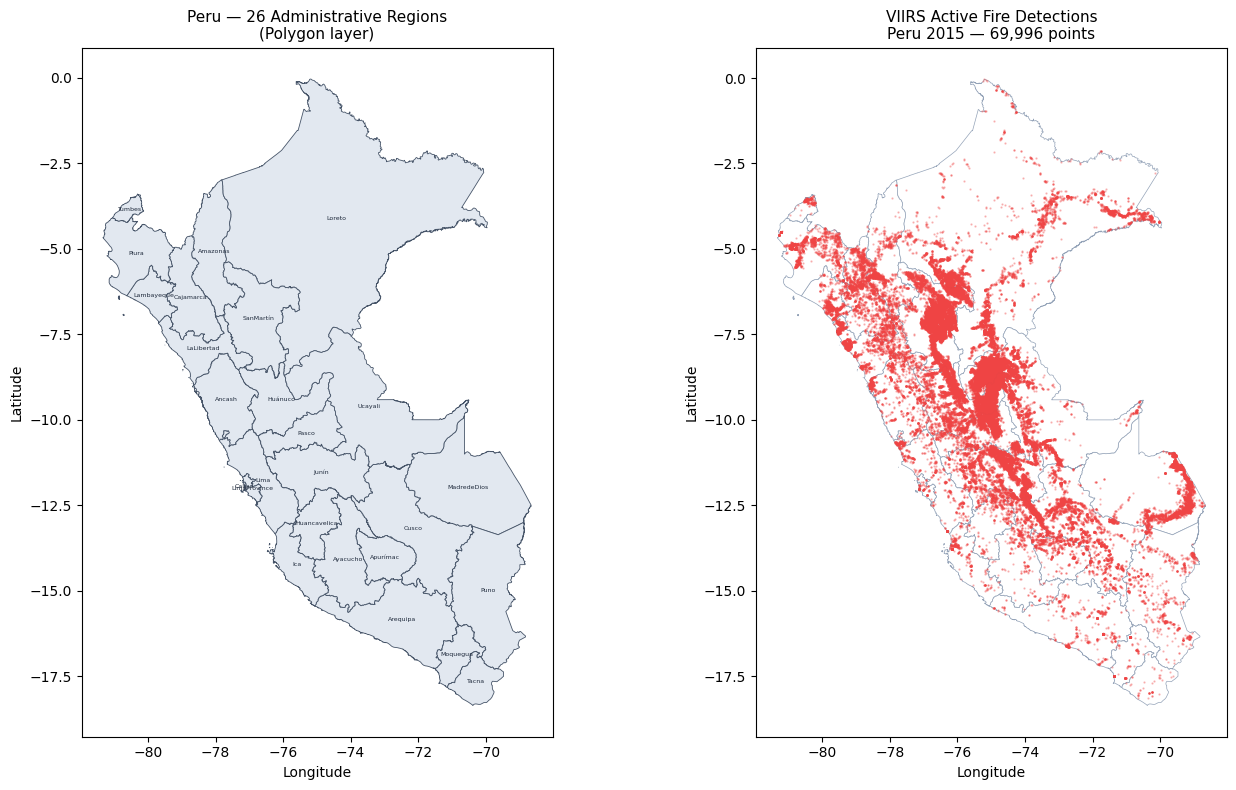

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: regions only
peru.plot(ax=axes[0], color='#e2e8f0', edgecolor='#475569', linewidth=0.6)
axes[0].set_title('Peru — 26 Administrative Regions\n(Polygon layer)', fontsize=11)
for _, row in peru.iterrows():
    c = row.geometry.centroid
    axes[0].text(c.x, c.y, row['NAME_1'], fontsize=4.5,
                 ha='center', va='center', color='#1e293b')

# Right: fires on top of regions
peru.plot(ax=axes[1], color='white', edgecolor='#94a3b8', linewidth=0.5)
fires.plot(ax=axes[1], color='#ef4444', markersize=0.4, alpha=0.35)
axes[1].set_title(f'VIIRS Active Fire Detections\nPeru {YEAR} — {len(fires):,} points', fontsize=11)

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

---
## Part 2 — Spatial Operations

### 2.1  Spatial Join — Which Region Does Each Fire Belong To?

A **spatial join** answers the question: *"which polygon does each point fall inside?"*  
No shared ID column is needed — just geometry.

```
fires (70,000 points)  +  peru (26 polygons)  →  joined (fires labeled with their region)
```

We use `predicate="within"` to keep only fires that fall completely inside a region polygon.

In [41]:
# Spatial join: assign each fire to a region
fires_joined = gpd.sjoin(
    fires,
    peru[['GID_1', 'NAME_1', 'geometry']],
    predicate='within',
    how='inner'    # drop fires that don't fall inside any region
)

print(f'Fires before join : {len(fires):,}')
print(f'Fires after join  : {len(fires_joined):,}   (some coastal points fall in the ocean)')
print(f'Unique regions    : {fires_joined["NAME_1"].nunique()}')

fires_joined[['latitude', 'longitude', 'acq_date', 'frp', 'NAME_1', 'GID_1']].head(5)

Fires before join : 69,996
Fires after join  : 69,936   (some coastal points fall in the ocean)
Unique regions    : 26


,latitude,longitude,acq_date,frp,NAME_1,GID_1
0,-17.20080,-70.95138,2015-01-01,2.81,Moquegua,PER.19_1
1,-17.20262,-70.94351,2015-01-01,2.31,Moquegua,PER.19_1
2,-17.20549,-70.95315,2015-01-01,2.71,Moquegua,PER.19_1
3,-7.10503,-76.51246,2015-01-01,1.21,SanMartín,PER.23_1
4,-17.49601,-71.36060,2015-01-01,5.94,Moquegua,PER.19_1


### 2.2  Aggregate — Count Fires Per Region

Now that each fire has a region label, we can group by region and count.  
This is just a standard pandas `groupby` — nothing spatial about this step.

In [42]:
# Count fires and sum FRP per region
fire_counts = (
    fires_joined
    .groupby('GID_1')
    .agg(
        n_fires   = ('latitude', 'count'),
        total_frp = ('frp', 'sum')
    )
    .reset_index()
)

print('Top 10 regions by fire count:')
top10 = fire_counts.merge(peru[['GID_1','NAME_1']], on='GID_1')
top10.sort_values('n_fires', ascending=False).head(10).round(1)

Top 10 regions by fire count:


,GID_1,n_fires,total_frp,NAME_1
14,PER.23_1,11557,102815.0,SanMartín
17,PER.26_1,11432,133180.8,Ucayali
0,PER.10_1,8716,111854.7,Huánuco
7,PER.17_1,6522,56665.6,Loreto
2,PER.12_1,6277,60266.0,Junín
8,PER.18_1,3730,50011.8,MadredeDios
24,PER.8_1,3513,36665.6,Cusco
11,PER.20_1,2869,33389.0,Pasco
22,PER.6_1,2301,20289.6,Cajamarca
3,PER.13_1,1949,13872.8,LaLibertad


In [43]:
# Join counts back to the polygon GeoDataFrame (for mapping)
peru_fires = peru.merge(fire_counts, on='GID_1', how='left')
peru_fires['n_fires']   = peru_fires['n_fires'].fillna(0).astype(int)
peru_fires['total_frp'] = peru_fires['total_frp'].fillna(0)

# Compute fires per 1,000 km² (normalize by region size)
peru_fires = peru_fires.merge(peru_m[['GID_1','area_km2']], on='GID_1')
peru_fires['fires_per_1000km2'] = (peru_fires['n_fires'] / peru_fires['area_km2'] * 1000).round(1)

peru_fires[['NAME_1', 'n_fires', 'total_frp', 'area_km2', 'fires_per_1000km2']].sort_values(
    'n_fires', ascending=False).head(8).round(0)

,NAME_1,n_fires,total_frp,area_km2,fires_per_1000km2
22,SanMartín,11557,102815.0,50380.0,229.0
25,Ucayali,11432,133181.0,105105.0,109.0
9,Huánuco,8716,111855.0,37068.0,235.0
16,Loreto,6522,56666.0,375527.0,17.0
11,Junín,6277,60266.0,44601.0,141.0
17,MadredeDios,3730,50012.0,84786.0,44.0
7,Cusco,3513,36666.0,72369.0,48.0
19,Pasco,2869,33389.0,23957.0,120.0


### 2.3  Choropleth Map — Visualize Fire Counts by Region

A **choropleth map** colors polygons by a numeric attribute.  
Here we use `geopandas .plot(column=...)` — no extra library needed.

We'll make two side-by-side maps:
1. Raw fire count per region
2. Fire density (fires per 1,000 km²) — fairer because large regions have more area

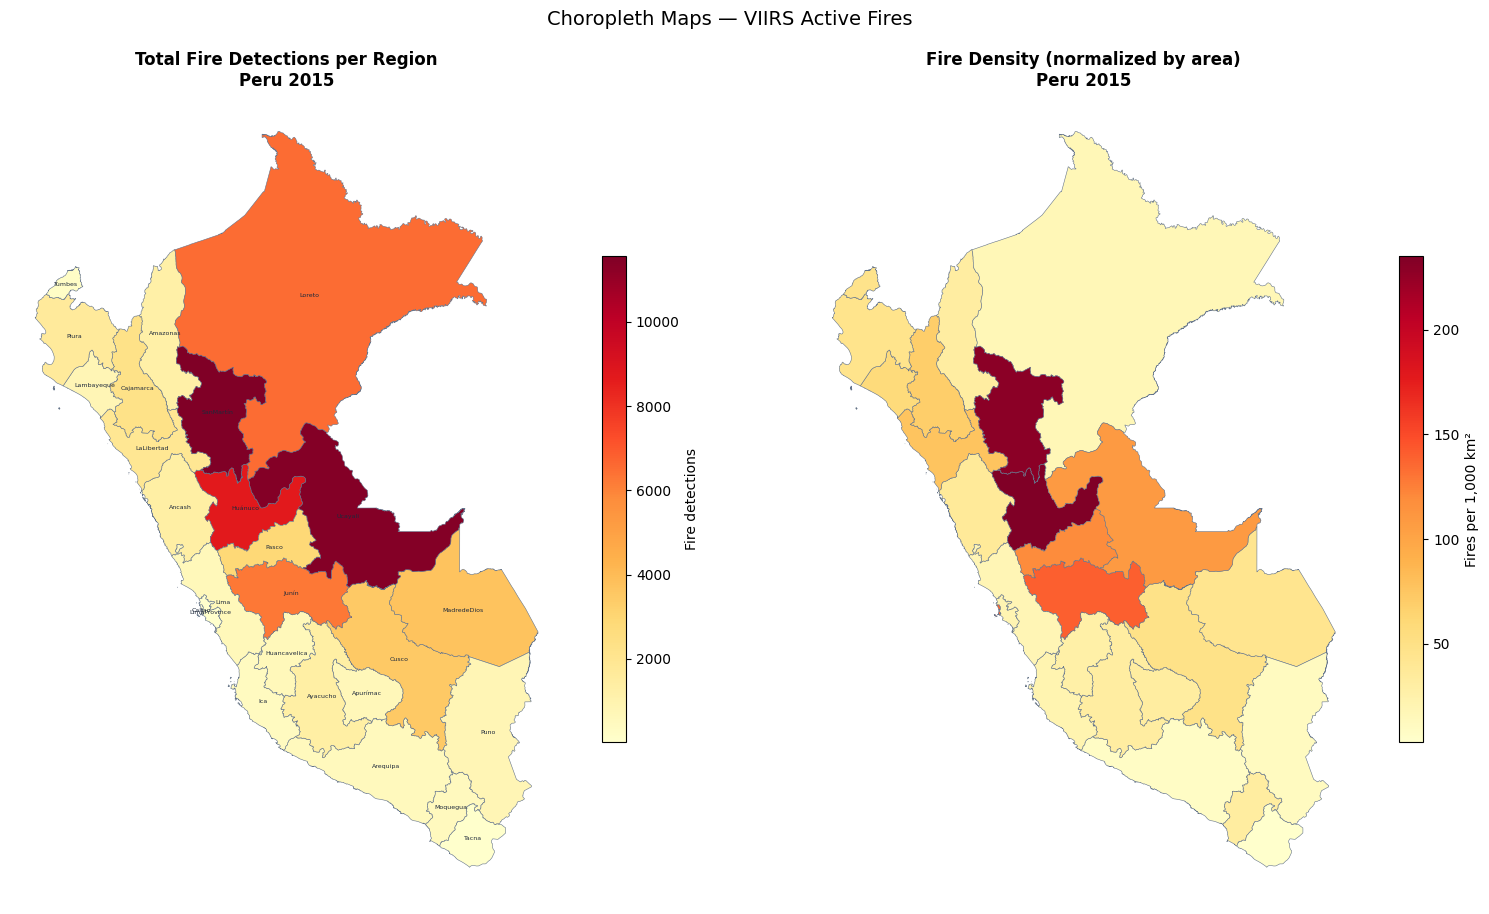

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# ── Left: raw fire count ──────────────────────────
peru_fires.plot(
    column='n_fires',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Fire detections', 'shrink': 0.6},
    edgecolor='#64748b',
    linewidth=0.4,
    ax=axes[0]
)
axes[0].set_title(f'Total Fire Detections per Region\nPeru {YEAR}', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# Add region name labels
for _, row in peru_fires.iterrows():
    c = row.geometry.centroid
    axes[0].text(c.x, c.y, row['NAME_1'], fontsize=4.5,
                 ha='center', va='center', color='#1e293b')

# ── Right: fires per 1,000 km² ───────────────────
peru_fires.plot(
    column='fires_per_1000km2',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Fires per 1,000 km²', 'shrink': 0.6},
    edgecolor='#64748b',
    linewidth=0.4,
    ax=axes[1]
)
axes[1].set_title(f'Fire Density (normalized by area)\nPeru {YEAR}', fontsize=12, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('Choropleth Maps — VIIRS Active Fires', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Reading the map:**  
The left map shows that large Amazonian regions (Ucayali, San Martín, Loreto) have the most total fires because they have more area.  
The right map (normalized) reveals which regions are disproportionately affected by fire relative to their size.

> This is why choropleth maps should often show **rates** (per area, per population) rather than raw counts.

### 2.4  Buffers — Proximity Zones Around Fires

A **buffer** creates a zone of all locations within distance *d* of a geometry.  

**Use cases:**
- Identify communities within 10 km of a fire
- Create exclusion zones around protected areas
- Convert point locations to area polygons

⚠️ Always reproject to a **metric CRS** (meters) before buffering.

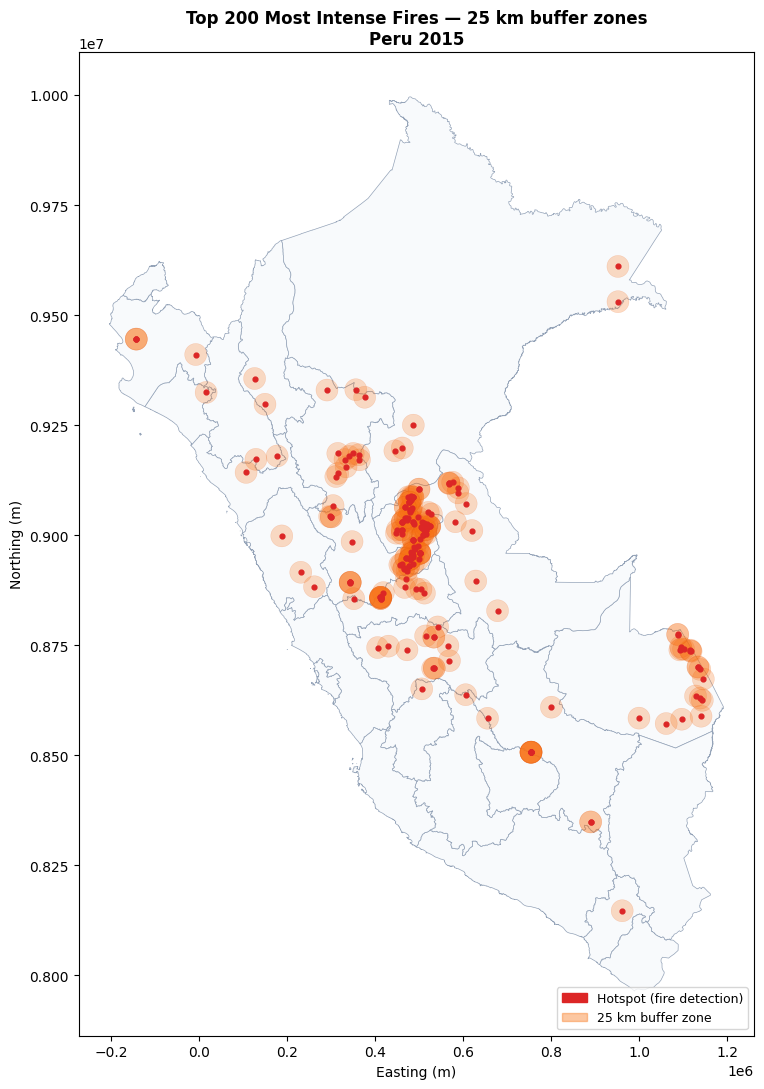

In [45]:
# Take the 200 most intense fires (highest FRP) as hotspots
hotspots = fires_joined.nlargest(200, 'frp').copy()

# Reproject to UTM 18S (meters) before buffering
hotspots_m = hotspots.to_crs('EPSG:32718')
peru_m_plot = peru.to_crs('EPSG:32718')

# Create 25 km buffer around each hotspot
hotspots_m['buffer_25km'] = hotspots_m.geometry.buffer(25_000)   # 25,000 m = 25 km

fig, ax = plt.subplots(figsize=(9, 11))
peru_m_plot.plot(ax=ax, color='#f8fafc', edgecolor='#94a3b8', linewidth=0.5)
hotspots_m.set_geometry('buffer_25km').plot(
    ax=ax, color='#f97316', alpha=0.25, edgecolor='#ea580c', linewidth=0.3
)
hotspots_m.plot(ax=ax, color='#dc2626', markersize=12, zorder=5)

ax.set_title(
    f'Top 200 Most Intense Fires — 25 km buffer zones\nPeru {YEAR}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

red_patch    = mpatches.Patch(color='#dc2626', label='Hotspot (fire detection)')
orange_patch = mpatches.Patch(color='#f97316', alpha=0.4, label='25 km buffer zone')
ax.legend(handles=[red_patch, orange_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In [46]:
# Advanced: dissolve all buffer circles into one union
# (shows total area at risk from the 200 most intense fires)
buffer_union = hotspots_m.set_geometry('buffer_25km').dissolve()

area_km2 = buffer_union.geometry.area.values[0] / 1e6
print(f'Total area within 25 km of a top-200 fire: {area_km2:,.0f} km²')

# Compare to Peru total area
peru_total_km2 = peru_m['area_km2'].sum()
print(f'Peru total area: {peru_total_km2:,.0f} km²')
print(f'Fraction affected: {area_km2/peru_total_km2*100:.1f}%')

Total area within 25 km of a top-200 fire: 136,834 km²
Peru total area: 1,294,504 km²
Fraction affected: 10.6%


### 2.5  Dissolve — Merge Polygons Into Larger Units

**Dissolve** merges multiple polygons that share an attribute value into a single shape, and aggregates their numeric columns at the same time.

Think of it as a **spatial group-by**.

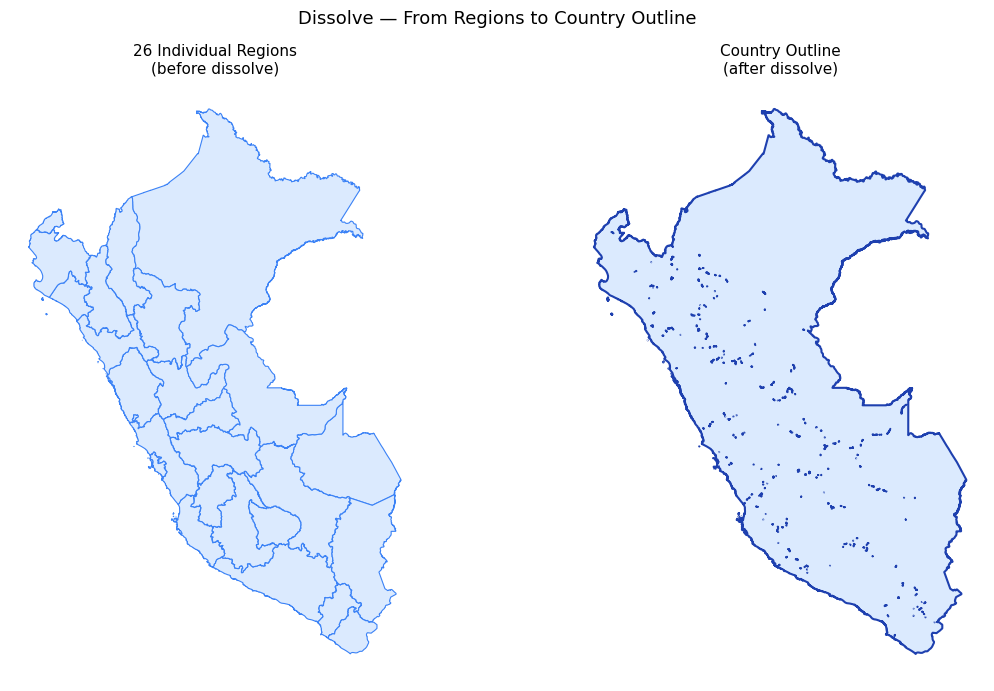

In [47]:
# Example 1: Dissolve all 26 regions into a single Peru country outline
peru_outline = peru.dissolve()

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

peru.plot(ax=axes[0], color='#dbeafe', edgecolor='#3b82f6', linewidth=0.8)
axes[0].set_title('26 Individual Regions\n(before dissolve)', fontsize=11)
axes[0].set_axis_off()

peru_outline.plot(ax=axes[1], color='#dbeafe', edgecolor='#1e40af', linewidth=1.5)
axes[1].set_title('Country Outline\n(after dissolve)', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('Dissolve — From Regions to Country Outline', fontsize=13)
plt.tight_layout()
plt.show()

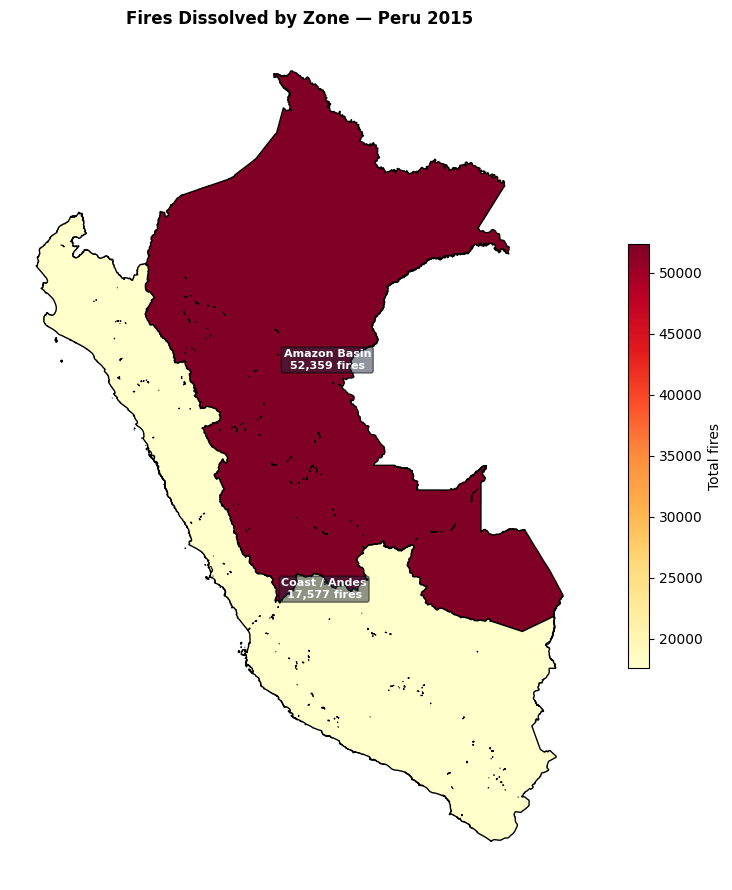

,zone,n_fires,total_frp
0,Amazon Basin,52359,558073.0
1,Coast / Andes,17577,154882.0


In [48]:
# Example 2: Dissolve with aggregation — group regions by Amazon basin membership
# (a simplified classification for illustration)
amazon_regions = [
    'Loreto', 'Ucayali', 'MadredeDios', 'Amazonas', 'SanMartín',
    'Huánuco', 'Pasco', 'Junín'
]
peru_fires['zone'] = peru_fires['NAME_1'].apply(
    lambda x: 'Amazon Basin' if x in amazon_regions else 'Coast / Andes'
)

# Dissolve by zone, sum the fire counts
zone_summary = peru_fires.dissolve(
    by='zone',
    aggfunc={'n_fires': 'sum', 'total_frp': 'sum'}
).reset_index()

fig, ax = plt.subplots(figsize=(8, 9))
zone_summary.plot(
    column='n_fires', cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Total fires', 'shrink': 0.5},
    edgecolor='black', linewidth=1,
    ax=ax
)
for _, row in zone_summary.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, f"{row['zone']}\n{row['n_fires']:,} fires",
            ha='center', va='center', fontsize=8, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#1e293b', alpha=0.5))

ax.set_title(f'Fires Dissolved by Zone — Peru {YEAR}', fontsize=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

zone_summary[['zone','n_fires','total_frp']].round(0)

### 2.6  Bonus — Monthly Fire Seasonality

Fires in Peru follow a strong seasonal pattern driven by the dry season (May–October).  
Let's aggregate by month to see this.

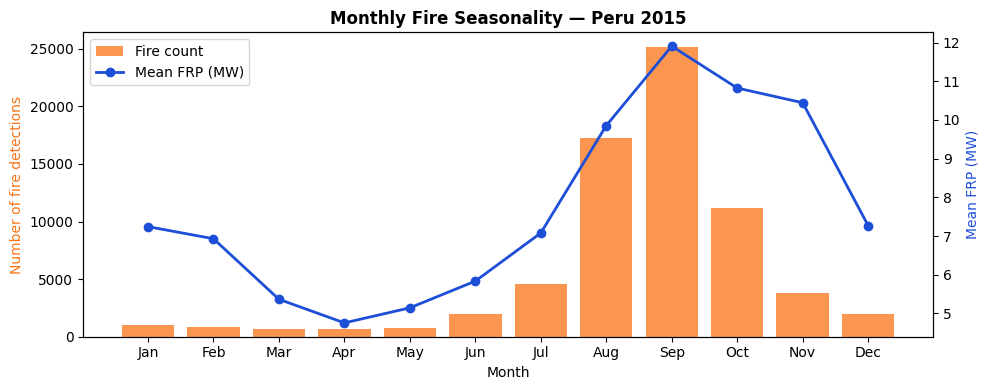

In [49]:
monthly = (
    fires_joined
    .groupby('month')
    .agg(n_fires=('latitude','count'), mean_frp=('frp','mean'))
    .reset_index()
)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(monthly['month_name'], monthly['n_fires'],
        color='#f97316', alpha=0.75, label='Fire count')
ax2.plot(monthly['month_name'], monthly['mean_frp'],
         color='#1d4ed8', marker='o', linewidth=2, label='Mean FRP (MW)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of fire detections', color='#f97316')
ax2.set_ylabel('Mean FRP (MW)', color='#1d4ed8')
ax1.set_title(f'Monthly Fire Seasonality — Peru {YEAR}', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

---
## Part 3 — Exercises

Apply what you've learned. Each exercise builds on the code above.

### Exercise 1 — Compare Years

Change `YEAR = 2015` at the top of the notebook to `YEAR = 2020` and re-run.  
Then answer:

1. Which year had more total fire detections?
2. Which region had the most fires in 2020?
3. Did the seasonal pattern change?

> **Hint:** VIIRS-SNPP data is available from 2012 to present.

### Exercise 2 — High-Confidence Fires Only

The `confidence` column has values `'h'` (high), `'n'` (nominal), `'l'` (low).  
Filter the fires to keep only **high-confidence** detections and redo the choropleth.

```python
fires_high = fires[fires['confidence'] == 'h'].copy()
```

Questions:
1. How many high-confidence fires are there vs the full dataset?
2. Does the regional ranking change when you filter?
3. Are high-confidence fires more intense on average (higher FRP)?

In [50]:
# Your code here


### Exercise 3 — Buffer Overlap

Create a 50 km buffer around the **top 50 most intense fires** and answer:
1. What fraction of Peru's total area is within 50 km of a top-50 fire?
2. Which region has the most overlap with these buffers?  
   Hint: use `gpd.overlay(region_layer, buffer_layer, how='intersection')` and compare areas.

```python
# Start here
top50 = fires_joined.nlargest(50, 'frp').to_crs('EPSG:32718')
top50['buf_50km'] = top50.geometry.buffer(50_000)
```

In [51]:
# Your code here


---
## Part 4 — Raster Data: Crop Yield by Province (Zonal Statistics)

So far we have worked entirely with **vector** data (points and polygons).  
Now we introduce **raster** data — gridded datasets where each cell stores a value.

### Dataset: Crop Yield — Peru 1982–2015

Format: **NetCDF** (`.nc`) — a multidimensional array: latitude × longitude × time.  
Each cell value = estimated crop yield in **kg per hectare**.

Source: https://data.mendeley.com/datasets/hg8wzgx4yp/3
We will:
1. Load Peru **Level-2 provinces** (≈ 196 provinces) from GADM
2. Load **Maize** and **Rice** yield rasters clipped to Peru
3. Use **zonal statistics** to compute the mean yield per province per year
4. Build a **time series** and plot production trends
5. Make a **choropleth** of long-run average yield by province

In [63]:
# Additional libraries for raster / NetCDF analysis
import xarray as xr
import numpy as np
from affine import Affine
from rasterstats import zonal_stats

print('xarray    :', xr.__version__)
print('rasterstats loaded')
print('affine    loaded')

xarray    : 2026.2.0
rasterstats loaded
affine    loaded


### 4.1  Load Peru Level-2 Provinces

Peru is divided into 26 **regions** (Level 1) and about **196 provinces** (Level 2).  
We download the Level-2 boundaries from GADM 4.1.

In [64]:
# Download Level-2 provincial boundaries
peru_l2 = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_2.json'
)
# Keep only key columns
peru_l2 = peru_l2[['GID_2', 'GID_1', 'NAME_1', 'NAME_2', 'geometry']].copy()

print(f'Provinces (Level 2): {len(peru_l2)}')
print(f'Regions   (Level 1): {peru_l2["NAME_1"].nunique()}')
print(f'CRS: {peru_l2.crs}')
peru_l2.head(5)

Provinces (Level 2): 195
Regions   (Level 1): 26
CRS: EPSG:4326


,GID_2,GID_1,NAME_1,NAME_2,geometry
0,PER.1.1_1,PER.1_1,Amazonas,Bagua,"MULTIPOLYGON (((-78.2914 -5.5534, -78.2886 -5...."
1,PER.1.2_1,PER.1_1,Amazonas,Bongará,"MULTIPOLYGON (((-77.7622 -5.8158, -77.7513 -5...."
2,PER.1.3_1,PER.1_1,Amazonas,Chachapoyas,"MULTIPOLYGON (((-77.782 -6.9465, -77.8002 -6.9..."
3,PER.1.4_1,PER.1_1,Amazonas,Condorcanqui,"MULTIPOLYGON (((-78.1018 -5.3489, -78.0991 -5...."
4,PER.1.5_1,PER.1_1,Amazonas,Luya,"MULTIPOLYGON (((-77.9253 -6.2485, -77.9321 -6...."


<Axes: >

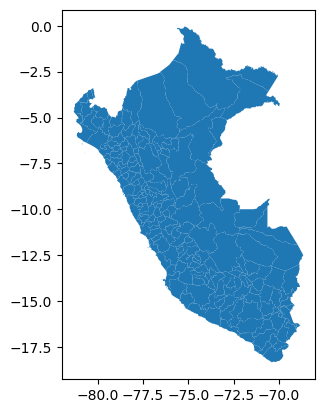

In [65]:
peru_l2.plot()

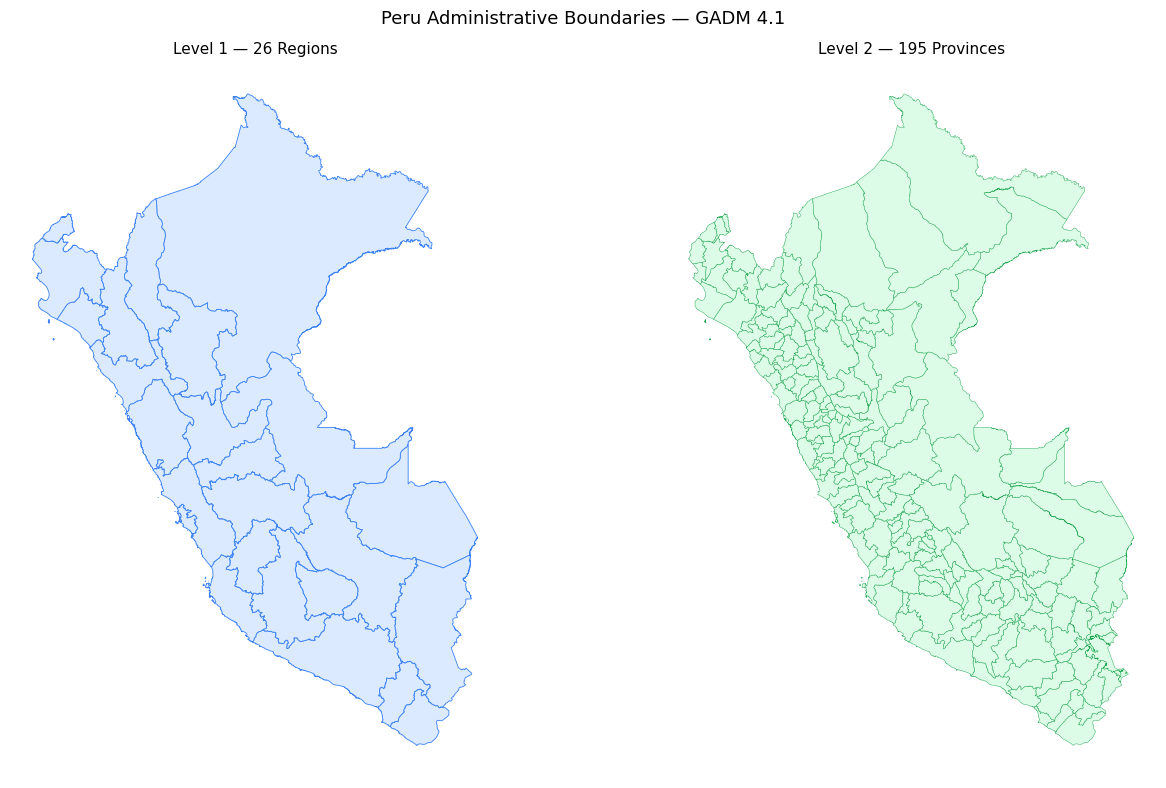

In [66]:
# Quick look at provincial boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: Level 1 regions
peru.plot(ax=axes[0], color='#dbeafe', edgecolor='#3b82f6', linewidth=0.6)
axes[0].set_title('Level 1 — 26 Regions', fontsize=11)
axes[0].set_axis_off()

# Right: Level 2 provinces
peru_l2.plot(ax=axes[1], color='#dcfce7', edgecolor='#16a34a', linewidth=0.3)
axes[1].set_title(f'Level 2 — {len(peru_l2)} Provinces', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('Peru Administrative Boundaries — GADM 4.1', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2  Load NetCDF Yield Rasters

The NetCDF files have three dimensions:

| Dimension | Size | Description |
|-----------|------|-------------|
| `time` | 34 | Years 1982–2015 |
| `lon` | 156 | Longitude columns |
| `lat` | 228 | Latitude rows |

> ⚠️ **Dimension order quirk:** The `Yield` variable is stored as `(time, lon, lat)` — longitude first, latitude second.  
> This is the opposite of the usual `(time, lat, lon)` = `(time, rows, cols)` convention.  
> We must **transpose** each 2-D slice before passing it to rasterstats.

In [67]:
# Load the clipped NetCDF files (pre-clipped to Peru bounding box)
maize_ds = xr.open_dataset('../_data/ncfiles/peru/Maize_Peru_1982_2015.nc')
rice_ds  = xr.open_dataset('../_data/ncfiles/peru/Rice_Peru_1982_2015.nc')

print('=== Maize ===')
print('  Dimensions:', dict(maize_ds.dims))
print('  Variables :', list(maize_ds.data_vars))
print('  Time range:', str(maize_ds.time.values[0])[:4], '→', str(maize_ds.time.values[-1])[:4])

print()
print('=== Rice ===')
print('  Dimensions:', dict(rice_ds.dims))
print('  Time range:', str(rice_ds.time.values[0])[:4], '→', str(rice_ds.time.values[-1])[:4])

# Peek at the spatial extent
lons = maize_ds.lon.values
lats = maize_ds.lat.values
print(f'\nLon range: {lons[0]:.3f}° → {lons[-1]:.3f}°  (ascending: {bool(lons[1]>lons[0])})')
print(f'Lat range: {lats[0]:.3f}° → {lats[-1]:.3f}°  (descending: {bool(lats[1]<lats[0])})')

=== Maize ===
  Dimensions: {'time': 34, 'lon': 156, 'lat': 228}
  Variables : ['Yield']
  Time range: 1982 → 2015

=== Rice ===
  Dimensions: {'time': 34, 'lon': 156, 'lat': 228}
  Time range: 1982 → 2015

Lon range: -81.458° → -68.542°  (ascending: True)
Lat range: 0.458° → -18.458°  (descending: True)


### 4.3  Building the Raster-to-Map Transform

Before running zonal statistics, we need to tell rasterstats **where** each raster cell sits on the Earth.  
This is done with an **Affine transform** — a 6-parameter matrix that maps pixel positions to geographic coordinates.

```
Affine(dlon, 0, west,
       0,   -dlat, north)
```

- `west` = longitude of the **left edge** of the leftmost pixel
- `north` = latitude of the **top edge** of the topmost pixel
- `dlon` = pixel width in degrees
- `dlat` = pixel height in degrees (negative sign because rows go south)

In [68]:
# Compute cell resolution from coordinate spacing
lon = maize_ds.lon.values
lat = maize_ds.lat.values

dlon = float(lon[1] - lon[0])          # ~0.0833° per cell (east)
dlat = float(lat[0] - lat[1])          # ~0.0833° per cell (south, positive value)

# Cell edges (half-pixel shift from cell centres)
west  = float(lon[0]) - dlon / 2       # left  edge of westernmost  column
north = float(lat[0]) + dlat / 2       # top   edge of northernmost row

transform = Affine(dlon, 0, west,
                   0,  -dlat, north)

print(f'Resolution : {dlon:.4f}° × {dlat:.4f}°')
print(f'West edge  : {west:.4f}°')
print(f'North edge : {north:.4f}°')
print(f'Affine     : {transform}')

# Sanity check: does the bounding box cover Peru?
east  = west  + dlon * len(lon)
south = north - dlat * len(lat)
print(f'\nBounding box: ({west:.2f}, {south:.2f}, {east:.2f}, {north:.2f})')
print('Expected Peru bounds: roughly (-82, -19, -68, 1)')

Resolution : 0.0833° × 0.0833°
West edge  : -81.5000°
North edge : 0.5000°
Affine     : | 0.08, 0.00,-81.50|
| 0.00,-0.08, 0.50|
| 0.00, 0.00, 1.00|

Bounding box: (-81.50, -18.50, -68.50, 0.50)
Expected Peru bounds: roughly (-82, -19, -68, 1)


### 4.4  Zonal Statistics — Mean Yield per Province per Year

**Zonal statistics** answer: *"for each polygon, what is the average (or sum, max, …) of all raster cells that fall inside it?"*

For each of the 34 years, we:
1. Extract the 2-D yield array for that year: shape `(lon, lat)`
2. Transpose it to `(lat, lon)` = `(rows, cols)` as expected by rasterstats
3. Call `zonal_stats(provinces, array, affine=transform, stats=['mean'])`
4. Store one record per province per year

This loop runs 34 × 2 = 68 raster passes over ~196 polygons — typically takes 15–60 seconds.

In [69]:
def compute_yield_timeseries(ds, crop_name, provinces, transform):
    """Return a DataFrame with mean yield per province per year."""
    records = []
    years = [int(str(t)[:4]) for t in ds.time.values]

    for t_idx, year in enumerate(years):
        # Extract 2-D slice, then transpose: (lon,lat) → (lat,lon) = (rows,cols)
        arr = ds['Yield'][t_idx].values.T
        arr = arr.astype(float)

        stats = zonal_stats(
            provinces,
            arr,
            affine=transform,
            stats=['mean'],
            nodata=np.nan,
            all_touched=False
        )

        for i, row in provinces.iterrows():
            mean_val = stats[i].get('mean')
            records.append({
                'GID_2'          : row['GID_2'],
                'NAME_1'         : row['NAME_1'],
                'NAME_2'         : row['NAME_2'],
                'year'           : year,
                'crop'           : crop_name,
                'mean_yield_kgha': mean_val
            })

    return pd.DataFrame(records)

print('Computing zonal stats for Maize …')
df_maize = compute_yield_timeseries(maize_ds, 'Maize', peru_l2, transform)

print('Computing zonal stats for Rice …')
df_rice  = compute_yield_timeseries(rice_ds,  'Rice',  peru_l2, transform)

# Combine both crops
df_yield = pd.concat([df_maize, df_rice], ignore_index=True)

print(f'\nTotal records: {len(df_yield):,}')
print(f'Years        : {df_yield.year.min()} – {df_yield.year.max()}')
print(f'Provinces    : {df_yield.GID_2.nunique()}')
print(f'Crops        : {df_yield.crop.unique()}')
df_yield.head(6)

Computing zonal stats for Maize …
Computing zonal stats for Rice …

Total records: 13,260
Years        : 1982 – 2015
Provinces    : 195
Crops        : ['Maize' 'Rice']


,GID_2,NAME_1,NAME_2,year,crop,mean_yield_kgha
0,PER.1.1_1,Amazonas,Bagua,1982,Maize,3276.627500
1,PER.1.2_1,Amazonas,Bongará,1982,Maize,NaN
2,PER.1.3_1,Amazonas,Chachapoyas,1982,Maize,3128.038000
3,PER.1.4_1,Amazonas,Condorcanqui,1982,Maize,2656.394000
4,PER.1.5_1,Amazonas,Luya,1982,Maize,2959.507586
5,PER.1.6_1,Amazonas,RodríguezdeMendoza,1982,Maize,NaN


In [74]:
(13260/195)/2

34.0

### 4.5  Time Series — Top Producing Provinces

For each crop we:
1. Compute the long-run mean yield per province (averaged over all 34 years)
2. Select the **top 5 provinces** by mean yield
3. Plot their annual yield trends side by side

This reveals not just which provinces produce the most, but also **how yields have changed over time** — capturing technology adoption, climate shifts, or policy effects.

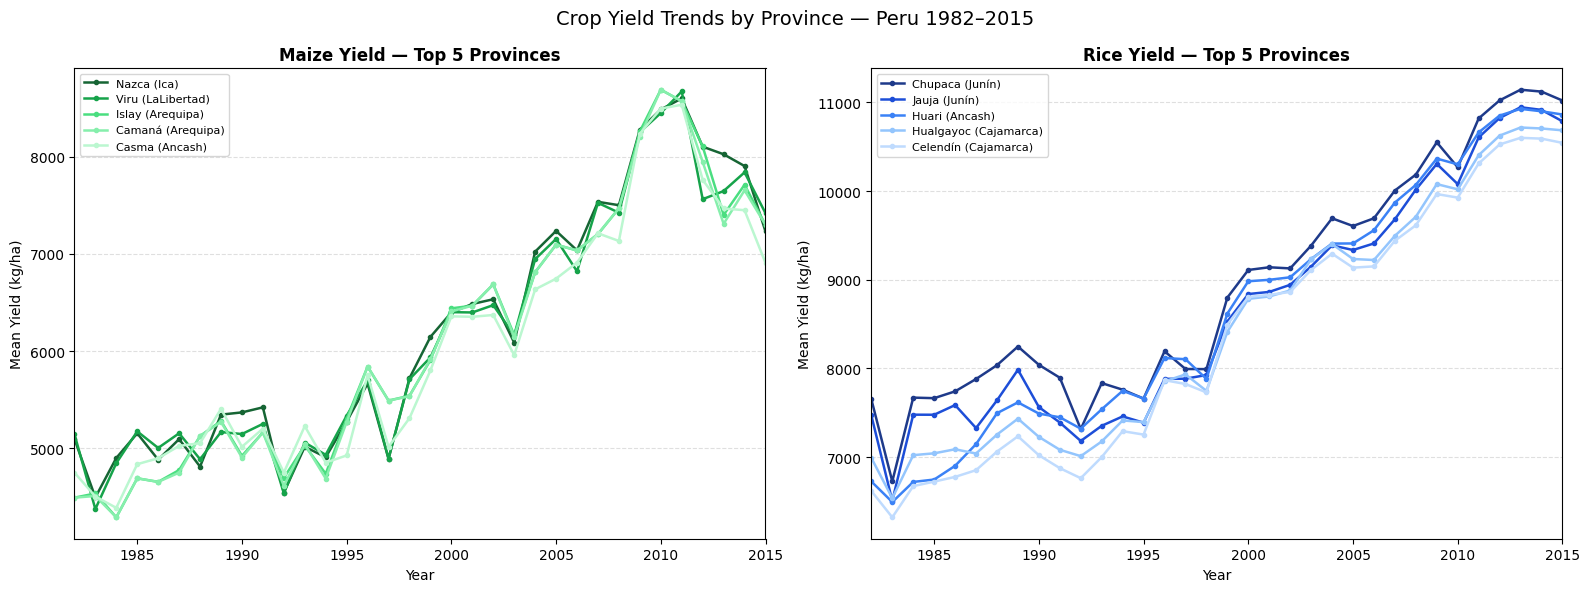

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

crop_colors = {
    'Maize': ['#166534','#16a34a','#4ade80','#86efac','#bbf7d0'],
    'Rice' : ['#1e3a8a','#1d4ed8','#3b82f6','#93c5fd','#bfdbfe'],
}

for ax, crop in zip(axes, ['Maize', 'Rice']):
    sub = df_yield[df_yield['crop'] == crop].dropna(subset=['mean_yield_kgha'])

    # Compute long-run mean per province and pick top 5
    prov_mean = (
        sub.groupby(['GID_2','NAME_1','NAME_2'])['mean_yield_kgha']
           .mean()
           .reset_index()
           .sort_values('mean_yield_kgha', ascending=False)
    )
    # Keep provinces with actual data in majority of years
    prov_counts = sub.groupby('GID_2')['mean_yield_kgha'].count()
    valid_provs = prov_counts[prov_counts >= 20].index
    prov_mean   = prov_mean[prov_mean['GID_2'].isin(valid_provs)]
    top5_ids    = prov_mean.head(5)['GID_2'].tolist()

    colors = crop_colors[crop]
    for idx, gid in enumerate(top5_ids):
        prov_data = sub[sub['GID_2'] == gid].sort_values('year')
        name = prov_data['NAME_2'].iloc[0]
        region = prov_data['NAME_1'].iloc[0]
        ax.plot(
            prov_data['year'],
            prov_data['mean_yield_kgha'],
            marker='o', markersize=3,
            color=colors[idx],
            linewidth=1.8,
            label=f'{name} ({region})'
        )

    ax.set_title(f'{crop} Yield — Top 5 Provinces', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Yield (kg/ha)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(1982, 2015)

plt.suptitle('Crop Yield Trends by Province — Peru 1982–2015', fontsize=14)
plt.tight_layout()
plt.show()

**Reading the chart:**
- An **upward trend** indicates yield improvements — possibly better seed varieties, irrigation, or fertiliser use.
- **Flat or declining trends** may reflect climate stress, soil degradation, or abandonment of marginal land.
- The spread between provinces shows **geographic inequality** in agricultural productivity.

### 4.6  Choropleth — Long-Run Average Yield by Province

Aggregating across all 34 years gives a map of **structural productivity**: which provinces are persistently high or low yield?

In [76]:
# Download Peru Level-1 regions from GADM 4.1
peru = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_1.json'
)
# Keep only the columns we need
peru = peru[['GID_1', 'NAME_1', 'geometry']].copy()

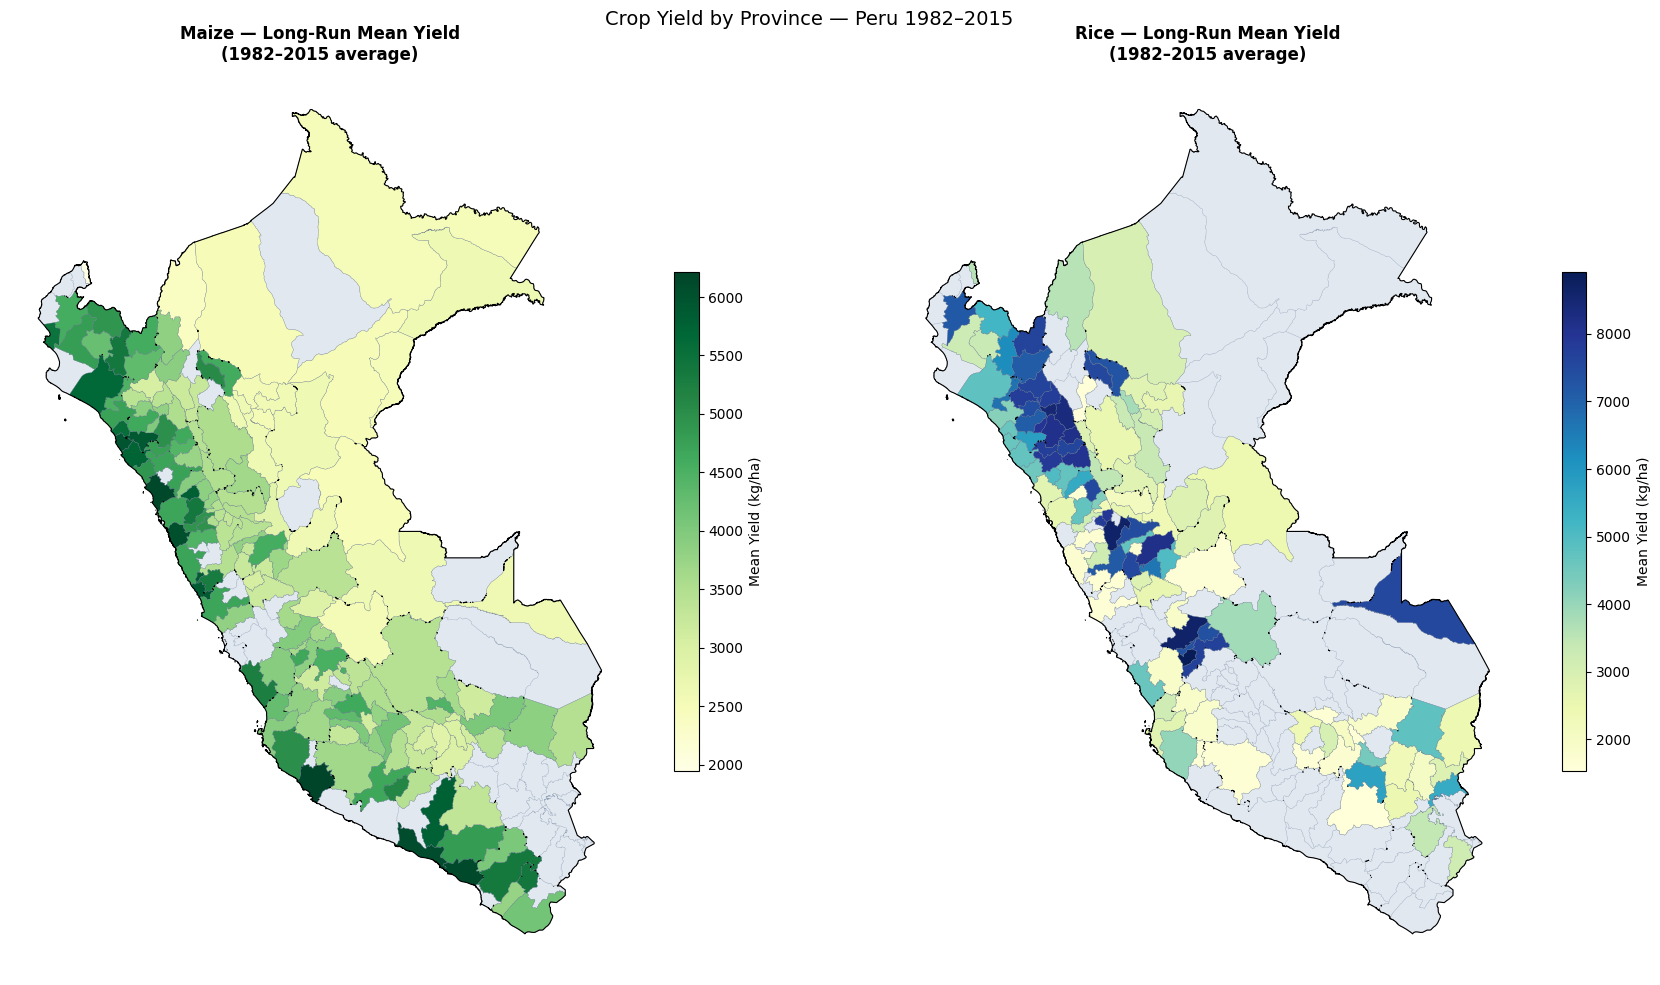

In [77]:
# Long-run mean per province per crop
mean_yield = (
    df_yield
    .dropna(subset=['mean_yield_kgha'])
    .groupby(['GID_2','crop'])['mean_yield_kgha']
    .mean()
    .reset_index()
    .rename(columns={'mean_yield_kgha': 'mean_yield_1982_2015'})
)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
cmaps = {'Maize': 'YlGn', 'Rice': 'YlGnBu'}

for ax, crop in zip(axes, ['Maize', 'Rice']):
    crop_data = mean_yield[mean_yield['crop'] == crop]
    plot_gdf  = peru_l2.merge(crop_data[['GID_2','mean_yield_1982_2015']], on='GID_2', how='left')

    # Provinces with no data (outside crop range) shown in grey
    plot_gdf.plot(
        ax=ax,
        color='#e2e8f0',     # grey = no data
        edgecolor='#94a3b8',
        linewidth=0.2
    )
    plot_gdf[plot_gdf['mean_yield_1982_2015'].notna()].plot(
        column='mean_yield_1982_2015',
        cmap=cmaps[crop],
        legend=True,
        legend_kwds={'label': 'Mean Yield (kg/ha)', 'shrink': 0.55},
        edgecolor='#64748b',
        linewidth=0.2,
        ax=ax
    )
    # Country outline
    peru.dissolve().boundary.plot(ax=ax, color='black', linewidth=0.8)

    ax.set_title(f'{crop} — Long-Run Mean Yield\n(1982–2015 average)', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Crop Yield by Province — Peru 1982–2015', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting the map:**
- **Dark green / blue** = high-yield provinces (favorable climate, irrigation, better agricultural practices)
- **Light colors** = low-yield areas (highland agriculture, rain-fed, or marginal land)
- **Grey** = no data for that province × crop combination (crop may not be grown there)

> This is the power of combining **vector** boundaries with **raster** data — zonal statistics bridge the two worlds and let you answer: *"which administrative unit produces the most of X?"*

---
### Part 4 Summary

| Step | Tool | What we did |
|------|------|-------------|
| Load raster | `xarray.open_dataset()` | Opened `.nc` file as labeled multi-dim array |
| Inspect dims | `ds.dims`, `ds.data_vars` | Found `(time, lon, lat)` order quirk |
| Affine transform | `Affine(dlon, 0, west, 0, -dlat, north)` | Mapped pixel positions to geographic coords |
| Zonal stats | `rasterstats.zonal_stats()` | Mean yield per province per year |
| Time series | pandas + matplotlib | Trend lines per province |
| Choropleth | `geopandas .plot(column=...)` | Long-run spatial pattern |

---
## Summary — What We Covered

| Concept | Applied to |
|---------|------------|
| **Point** geometry | Each VIIRS fire detection |
| **Polygon** geometry | Peru administrative regions |
| **CRS check & reproject** | EPSG:4326 → EPSG:32718 for areas/buffers |
| **Spatial join** | Assign each fire to its region |
| **Aggregation** | Count fires and sum FRP per region |
| **Choropleth map** | `.plot(column=..., cmap=...)` |
| **Buffer** | 25 km zones around intense fires |
| **Dissolve** | Regions → country outline; regions → zones |
| **NetCDF / raster** | `xr.open_dataset()` + Affine transform |
| **Zonal statistics** | Mean crop yield per province per year |
| **Time series** | Yield trends for top-5 provinces per crop |

---

**Next Lecture (Lecture 2):** Interactive maps with Folium — see `Lectures/Lecture2_InteractiveMaps.ipynb`.

**Reference notebook:** `slides/spatial_analysis_python.ipynb` — full cheatsheet with synthetic examples for all operations.

*Anzony Quispe · 2026*